# Sky localization maps

In [373]:
# 🎨 Matplotlib Style Configuration (Light & Dark Mode Compatible)
# Run this cell once at the beginning

import matplotlib
import matplotlib.pyplot as plt

# Universal matplotlib settings that work in both light and dark mode
matplotlib.rcParams.update({
    # High-quality output
    'figure.dpi': 100,              # Display DPI (screen)
    'savefig.dpi': 300,             # Save DPI (high quality for web)
    'figure.figsize': (10, 6),      # Default figure size in inches
    
    # Transparent backgrounds - adapts to page theme
    'savefig.transparent': True,
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    
    # Dark gray text - readable on both white and dark backgrounds
    'text.color': '#2d3748',        # Dark gray
    'axes.labelcolor': '#2d3748',
    'axes.edgecolor': '#4a5568',
    'xtick.color': '#2d3748',
    'ytick.color': '#2d3748',
    'axes.titlecolor': '#1a202c',   # Very dark gray (almost black)
    
    # Legend styling
    'legend.edgecolor': '#4a5568',
    'legend.facecolor': 'none',
    
    # Grid styling - subtle gray
    'grid.color': '#718096',
    'grid.alpha': 0.3,
})

print("✅ Matplotlib configured for universal compatibility")
print("📝 Plot text uses dark gray - readable on both light and dark backgrounds")
print("🎨 Transparent backgrounds adapt to your page theme")
print("🖼️  High quality: 300 DPI for saved figures, consistent sizing")

✅ Matplotlib configured for universal compatibility
📝 Plot text uses dark gray - readable on both light and dark backgrounds
🎨 Transparent backgrounds adapt to your page theme
🖼️  High quality: 300 DPI for saved figures, consistent sizing


In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
%matplotlib inline

## 1. Load a LIGO/Virgo Flat HEALPix Sky Map 
Example: S251112cm

In [12]:
import gzip
import urllib.request
from io import BytesIO
import healpy as hp
import tempfile
import os

# Download and read directly from GraceDB without saving permanently
url = 'https://gracedb.ligo.org/api/superevents/S251112cm/files/bayestar.fits.gz'

print(f"Downloading from {url}...")
with urllib.request.urlopen(url) as response:
    compressed_data = response.read()

print("Decompressing in memory...")
with gzip.open(BytesIO(compressed_data), 'rb') as f_in:
    fits_data = f_in.read()

# Create temporary file for healpy to read
with tempfile.NamedTemporaryFile(suffix='.fits', delete=False) as tmp:
    tmp.write(fits_data)
    tmp_path = tmp.name

try:
    # Use healpy to read the map properly (handles NESTED/RING ordering automatically)
    print("Reading HEALPix map...")
    m, header = hp.read_map(tmp_path, h=True, verbose=False)
    header = dict(header)
finally:
    # Clean up temporary file
    os.unlink(tmp_path)

print(f"✅ Map loaded successfully!")
print(f"Nside = {header['NSIDE']}, Ordering = {header['ORDERING']}")
print(f"Number of pixels = {len(m):,}")


Decompressing in memory...
Reading HEALPix map...
✅ Map loaded successfully!
Nside = 512, Ordering = NESTED
Number of pixels = 3,145,728
Decompressing in memory...
Reading HEALPix map...
✅ Map loaded successfully!
Nside = 512, Ordering = NESTED
Number of pixels = 3,145,728


/var/folders/5q/zf85wh2d0sxgdd55ws_1kk94pzxs0q/T/ipykernel_38104/1958328013.py:27: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m, header = hp.read_map(tmp_path, h=True, verbose=False)


In [8]:
m

array([1.59124749e-11, 1.59124749e-11, 1.59124749e-11, ...,
       1.10527216e-10, 1.10527216e-10, 1.10527216e-10], dtype='>f8')

## 2. Understanding HEALPix Map Orderings

HEALPix maps can be stored in two different orderings:

- **RING ordering**: Pixels are arranged in horizontal rings of constant latitude, numbered from north to south pole
- **NESTED ordering**: Pixels follow a hierarchical quad-tree structure, where nearby pixels have nearby indices. **Best for computation, indexing, and hierarchical methods**


In [13]:
nside = hp.get_nside(m)        # or header['NSIDE']
npix = hp.nside2npix(nside)
print(f"Nside: {nside}")
print(f"Total pixels on the sky: {npix:,}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Nside: 512
Total pixels on the sky: 3,145,728
Pixel area: 0.0131 deg²


$$N_{\text{pix}} = 12 \, \text{NSIDE}^2$$

## 3. Visualize the Sky Map (Mollweide Projection)

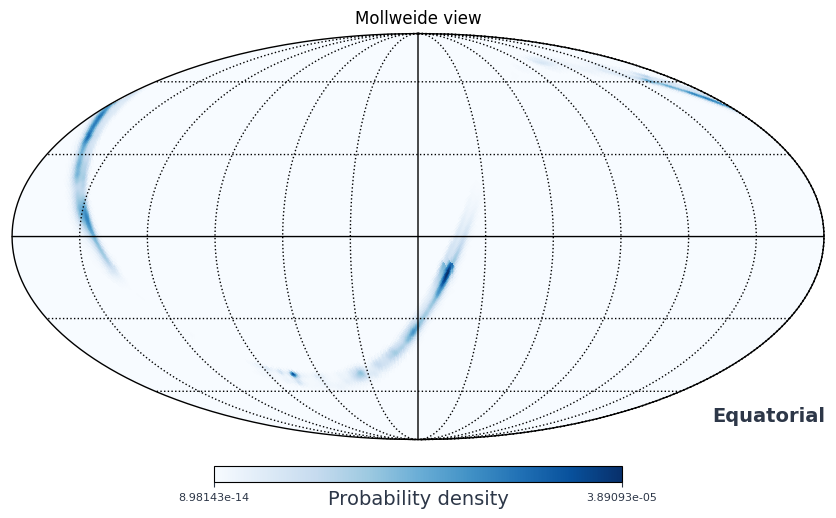

In [14]:
hp.mollview(m, unit="Probability density", coord='C', cmap='Blues')
hp.graticule()

# Make plot transparent and text dark gray for universal compatibility
fig = plt.gcf()
fig.patch.set_alpha(0)
text_color = '#2d3748'  # Dark gray - works on both light and dark backgrounds

for ax in fig.axes:
    ax.patch.set_alpha(0)
    # Make all text elements dark gray
    for text in ax.texts:
        text.set_color(text_color)
    ax.tick_params(colors=text_color, which='both', labelsize=8)
    
    # Colorbar text
    if hasattr(ax, 'collections'):
        for coll in ax.collections:
            if hasattr(coll, 'colorbar') and coll.colorbar:
                coll.colorbar.ax.tick_params(colors=text_color)
                coll.colorbar.ax.yaxis.label.set_color(text_color)

### Careful about rotated axes!! Zero RA point is at the center of the map

## 4. Find the Highest-Probability Pixel & Convert to Sky Coordinates

In [379]:
ipix_max = np.argmax(m)
theta, phi = hp.pix2ang(nside, ipix_max)
ra_deg = np.degrees(phi)
dec_deg = 90 - np.degrees(theta)

print(f"Highest probability pixel index: {ipix_max}")
print(f"RA, Dec = {ra_deg:.4f}°, {dec_deg:.4f}°")

Highest probability pixel index: 1940405
RA, Dec = 346.8164°, -13.4781°


## 5. Compute Credible Levels (50%, 90%, etc.)